# 04 -- Feature Engineering

**Project:** Early Disease Risk Predictor  
**Phase:** 2 -- Data Acquisition and Preprocessing  
**Notebook:** Normalisation, Scaling and Encoding  

This notebook covers:
1. Log transformation of skewed features
2. Encoding of categorical variables
3. Feature scaling (StandardScaler and MinMaxScaler)
4. Construction of per-disease feature matrices
5. Saving final processed datasets ready for model training


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import joblib

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROC_DIR = os.path.join('..', 'data', 'processed')
FIGS_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIGS_DIR, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup complete.')


Setup complete.


## 1. Load Master Dataset

In [2]:
master = pd.read_csv(os.path.join(PROC_DIR, 'master.csv'))

CONTINUOUS = ['age', 'bmi', 'glucose', 'blood_pressure', 'insulin', 'cholesterol']
LABEL_COLS = ['has_diabetes', 'has_heart_disease', 'has_hypertension']

print('Shape:', master.shape)
print('Columns:', list(master.columns))
master.head()


Shape: (5311, 10)
Columns: ['age', 'bmi', 'glucose', 'blood_pressure', 'insulin', 'source', 'has_diabetes', 'has_heart_disease', 'has_hypertension', 'cholesterol']


,age,bmi,glucose,blood_pressure,insulin,source,has_diabetes,has_heart_disease,has_hypertension,cholesterol
0,50.0000,33.6000,148.0000,72.0000,125.0000,pima,1,0,0,234.0000
1,31.0000,26.6000,85.0000,66.0000,125.0000,pima,0,0,0,234.0000
2,32.0000,23.3000,183.0000,64.0000,125.0000,pima,1,0,0,234.0000
3,21.0000,28.1000,89.0000,66.0000,112.8750,pima,0,0,0,234.0000
4,33.0000,43.1000,137.0000,40.0000,135.8750,pima,1,0,0,234.0000


## 2. Skewness Check

Features with absolute skewness > 0.75 are candidates for log transformation. Reducing skew improves model convergence and prevents a few extreme values from dominating distance-based calculations.


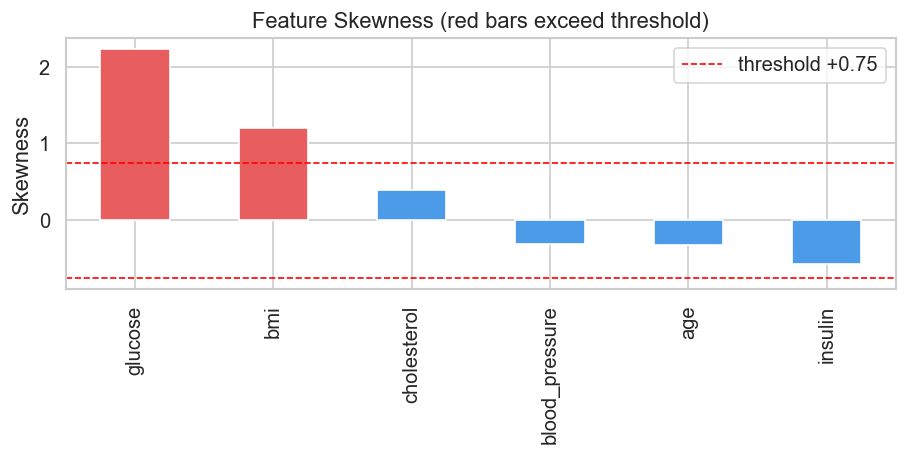

Features to log-transform: ['glucose', 'bmi']


In [3]:
feat_cols = [c for c in CONTINUOUS if c in master.columns]
skewness = master[feat_cols].skew().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E85D5D' if abs(v) > 0.75 else '#4C9BE8' for v in skewness]
skewness.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0.75,  color='red',  linestyle='--', linewidth=1, label='threshold +0.75')
ax.axhline(-0.75, color='red',  linestyle='--', linewidth=1)
ax.set_title('Feature Skewness (red bars exceed threshold)')
ax.set_ylabel('Skewness')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '09_skewness.png'))
plt.show()

skew_to_transform = skewness[abs(skewness) > 0.75].index.tolist()
print('Features to log-transform:', skew_to_transform)


## 3. Log Transformation

Apply `log1p` (i.e. log(x + 1)) to skewed features. `log1p` is used instead of `log` to safely handle zero values.


  glucose: skew 2.230 -> 1.273
  bmi: skew 1.206 -> 0.546


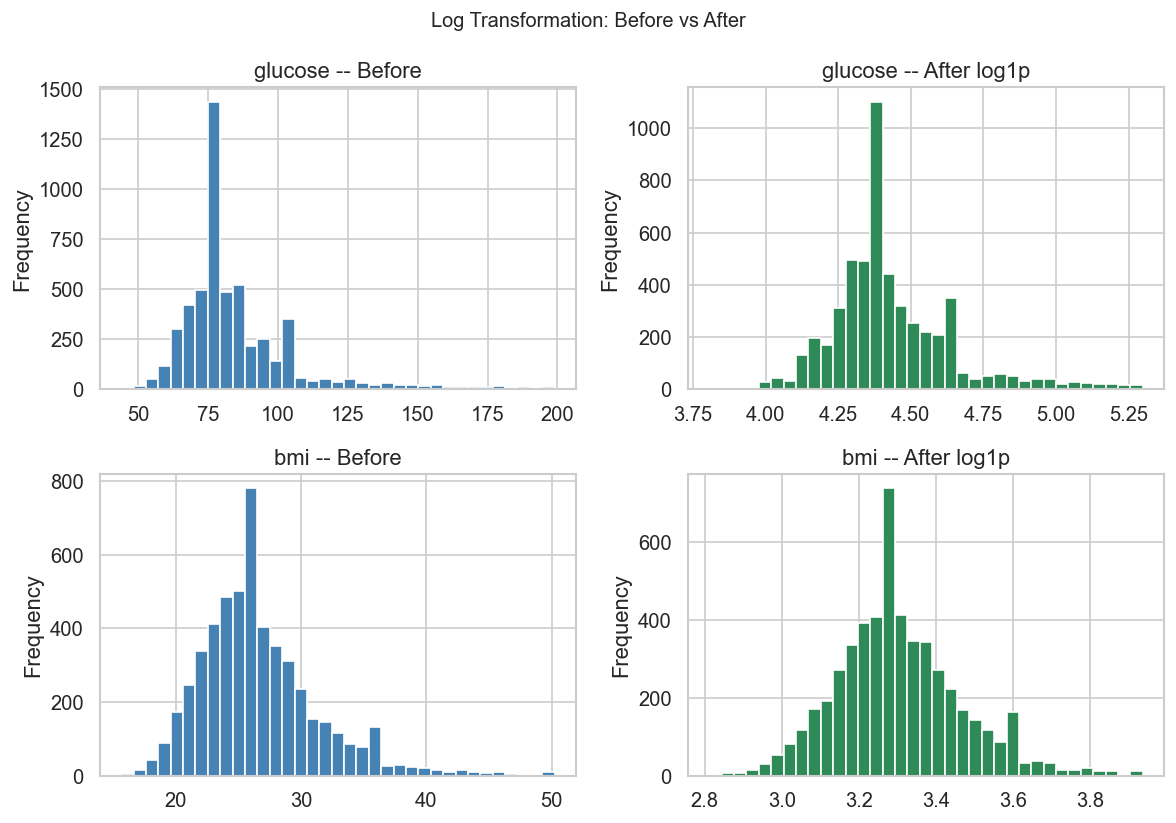

In [4]:
df = master.copy()

for col in skew_to_transform:
    before_skew = df[col].skew()
    df[col] = np.log1p(df[col])
    after_skew = df[col].skew()
    print(f'  {col}: skew {before_skew:.3f} -> {after_skew:.3f}')

# Visual before/after comparison
if skew_to_transform:
    fig, axes = plt.subplots(len(skew_to_transform), 2,
                             figsize=(10, 3.5 * len(skew_to_transform)))
    if len(skew_to_transform) == 1:
        axes = [axes]
    for row, col in zip(axes, skew_to_transform):
        master[col].dropna().plot.hist(bins=35, ax=row[0],
                                       color='steelblue', edgecolor='white')
        row[0].set_title(f'{col} -- Before')
        df[col].dropna().plot.hist(bins=35, ax=row[1],
                                   color='seagreen', edgecolor='white')
        row[1].set_title(f'{col} -- After log1p')
    plt.suptitle('Log Transformation: Before vs After', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, '10_log_transform.png'))
    plt.show()


## 4. Categorical Encoding

The `source` column is a nominal categorical variable. It is encoded with `pd.get_dummies` (one-hot encoding) to allow models to use source membership as a feature if needed. The `drop_first=True` argument avoids the dummy variable trap.


In [5]:
df = pd.get_dummies(df, columns=['source'], drop_first=True, dtype=int)

source_cols = [c for c in df.columns if c.startswith('source_')]
print('One-hot encoded source columns:', source_cols)
print('Shape after encoding:', df.shape)
df.head(3)


One-hot encoded source columns: ['source_pima', 'source_uci_heart']
Shape after encoding: (5311, 11)


,age,bmi,glucose,blood_pressure,insulin,has_diabetes,has_heart_disease,has_hypertension,cholesterol,source_pima,source_uci_heart
0,50.0000,3.5439,5.0039,72.0000,125.0000,1,0,0,234.0000,1,0
1,31.0000,3.3178,4.4543,66.0000,125.0000,0,0,0,234.0000,1,0
2,32.0000,3.1905,5.2149,64.0000,125.0000,1,0,0,234.0000,1,0


## 5. Feature Scaling

Two scalers are fitted and saved:
- **StandardScaler** (zero mean, unit variance) -- used for the XGBoost pipeline since tree models are scale-invariant, but standardisation is still useful for SHAP value comparability.
- **MinMaxScaler** (range 0-1) -- saved as an alternative for future neural network layers.

Scalers are fitted on the full processed dataset and saved to `data/processed/` so the exact same transformation can be applied to new inference inputs.


Scalers saved.


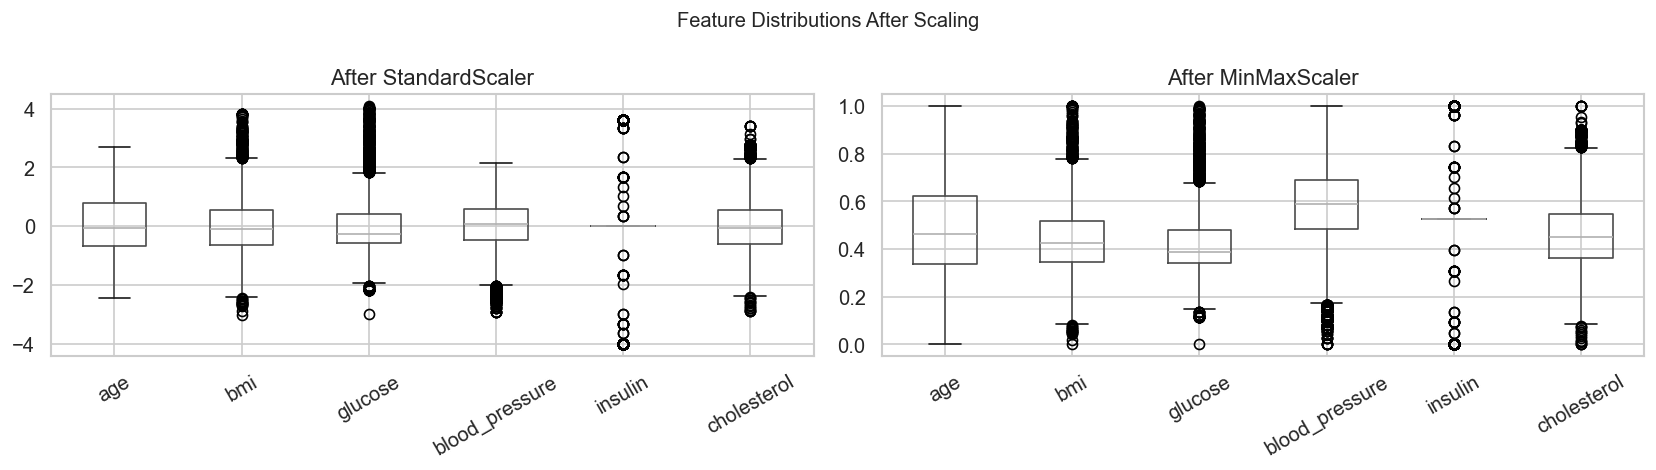

In [6]:
scale_cols = [c for c in CONTINUOUS if c in df.columns]

#  StandardScaler 
std_scaler = StandardScaler()
df_std = df.copy()
df_std[scale_cols] = std_scaler.fit_transform(df[scale_cols])

#  MinMaxScaler 
mm_scaler = MinMaxScaler()
df_mm = df.copy()
df_mm[scale_cols] = mm_scaler.fit_transform(df[scale_cols])

#  Save scalers 
joblib.dump(std_scaler, os.path.join(PROC_DIR, 'standard_scaler.pkl'))
joblib.dump(mm_scaler,  os.path.join(PROC_DIR, 'minmax_scaler.pkl'))
print('Scalers saved.')

#  Visualise scaled distributions 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_std[scale_cols].boxplot(ax=axes[0])
axes[0].set_title('After StandardScaler')
axes[0].tick_params(axis='x', rotation=30)
df_mm[scale_cols].boxplot(ax=axes[1])
axes[1].set_title('After MinMaxScaler')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('Feature Distributions After Scaling', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '11_scaled_distributions.png'))
plt.show()


## 6. Per-Disease Feature Matrices

Construct three separate X/y pairs, one per disease. Each uses `df_std` (StandardScaler version) as the feature base and drops the other two label columns to avoid target leakage.


In [7]:
feature_base = [c for c in df_std.columns if c not in LABEL_COLS]

datasets = {
    'diabetes'      : ('has_diabetes',      feature_base),
    'heart_disease' : ('has_heart_disease',  feature_base),
    'hypertension'  : ('has_hypertension',   feature_base),
}

for name, (label, feats) in datasets.items():
    X = df_std[feats]
    y = df_std[label]
    X.to_csv(os.path.join(PROC_DIR, f'X_{name}.csv'), index=False)
    y.to_csv(os.path.join(PROC_DIR, f'y_{name}.csv'), index=False)
    print(f'{name}: X={X.shape}, y={y.shape}, positive rate={y.mean():.3f}')


diabetes: X=(5311, 8), y=(5311,), positive rate=0.050
heart_disease: X=(5311, 8), y=(5311,), positive rate=0.147
hypertension: X=(5311, 8), y=(5311,), positive rate=0.379


## 7. Final Feature Summary

In [8]:
summary = pd.DataFrame({
    'feature'        : scale_cols,
    'original_mean'  : master[scale_cols].mean().values,
    'original_std'   : master[scale_cols].std().values,
    'original_skew'  : master[scale_cols].skew().values,
    'log_transformed': [c in skew_to_transform for c in scale_cols],
    'scaled_mean'    : df_std[scale_cols].mean().values,
    'scaled_std'     : df_std[scale_cols].std().values,
})
summary


,feature,original_mean,original_std,original_skew,log_transformed,scaled_mean,scaled_std
0,age,47.4887,10.8917,-0.3249,False,0.0000,1.0001
1,bmi,26.6911,4.8349,1.2060,True,-0.0000,1.0001
2,glucose,85.5280,21.4301,2.2297,True,0.0000,1.0001
3,blood_pressure,123.2709,28.5308,-0.3055,False,-0.0000,1.0001
4,insulin,124.9553,3.0096,-0.5730,False,0.0000,1.0001
5,cholesterol,236.3933,39.5306,0.3990,False,0.0000,1.0001
